Linear Regression : predicting a number        
Loigistic Regression: Classification

Linear Combination : Calculate the linear value
Credit-score, Income, Loan Amount             
Sigmoid Function

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
data = pd.read_excel('/content/CreditCard.xlsx')

In [9]:
data.head()

,rownames,card,reports,age,income,share,expenditure,owner,selfemp,dependents,months,majorcards,active
0,1,yes,0,37.66667,4.5200,0.033270,124.983300,yes,no,3,54,1,12
1,2,yes,0,33.25000,2.4200,0.005217,9.854167,no,no,3,34,1,13
2,3,yes,0,33.66667,4.5000,0.004156,15.000000,yes,no,4,58,1,5
3,4,yes,0,30.50000,2.5400,0.065214,137.869200,no,no,0,25,1,7
4,5,yes,0,32.16667,9.7867,0.067051,546.503300,yes,no,2,64,1,5


In [10]:
data_df = data.drop(columns=['rownames'])

In [11]:
data_df.describe()

,reports,age,income,share,expenditure,dependents,months,majorcards,active
count,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000
mean,0.456406,33.213103,3.365376,0.068732,185.057071,0.993935,55.267627,0.817286,6.996967
std,1.345267,10.142783,1.693902,0.094656,272.218917,1.247745,66.271746,0.386579,6.305812
min,0.000000,0.166667,0.210000,0.000109,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,25.416670,2.243750,0.002316,4.583333,0.000000,12.000000,1.000000,2.000000
50%,0.000000,31.250000,2.900000,0.038827,101.298300,1.000000,30.000000,1.000000,6.000000
75%,0.000000,39.416670,4.000000,0.093617,249.035800,2.000000,72.000000,1.000000,11.000000
max,14.000000,83.500000,13.500000,0.906320,3099.505000,6.000000,540.000000,1.000000,46.000000


In [12]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   card         1319 non-null   object 
 1   reports      1319 non-null   int64  
 2   age          1319 non-null   float64
 3   income       1319 non-null   float64
 4   share        1319 non-null   float64
 5   expenditure  1319 non-null   float64
 6   owner        1319 non-null   object 
 7   selfemp      1319 non-null   object 
 8   dependents   1319 non-null   int64  
 9   months       1319 non-null   int64  
 10  majorcards   1319 non-null   int64  
 11  active       1319 non-null   int64  
dtypes: float64(4), int64(5), object(3)
memory usage: 123.8+ KB


In [13]:
data_df['owner'] = data_df['owner'].apply(lambda x: 1 if x == 'yes' else 0)

In [14]:
data_df.head()

,card,reports,age,income,share,expenditure,owner,selfemp,dependents,months,majorcards,active
0,yes,0,37.66667,4.5200,0.033270,124.983300,1,no,3,54,1,12
1,yes,0,33.25000,2.4200,0.005217,9.854167,0,no,3,34,1,13
2,yes,0,33.66667,4.5000,0.004156,15.000000,1,no,4,58,1,5
3,yes,0,30.50000,2.5400,0.065214,137.869200,0,no,0,25,1,7
4,yes,0,32.16667,9.7867,0.067051,546.503300,1,no,2,64,1,5


In [15]:
data_df['selfemp'] = data_df['selfemp'].apply(lambda x: 1 if x == 'yes' else 0)
data_df['card'] = data_df['card'].apply(lambda x: 1 if x == 'yes' else 0)

In [16]:
data_df.head()

,card,reports,age,income,share,expenditure,owner,selfemp,dependents,months,majorcards,active
0,1,0,37.66667,4.5200,0.033270,124.983300,1,0,3,54,1,12
1,1,0,33.25000,2.4200,0.005217,9.854167,0,0,3,34,1,13
2,1,0,33.66667,4.5000,0.004156,15.000000,1,0,4,58,1,5
3,1,0,30.50000,2.5400,0.065214,137.869200,0,0,0,25,1,7
4,1,0,32.16667,9.7867,0.067051,546.503300,1,0,2,64,1,5


In [17]:
data_df['card'].value_counts()

,count
card,
1,1023
0,296


<Axes: xlabel='dependents', ylabel='count'>

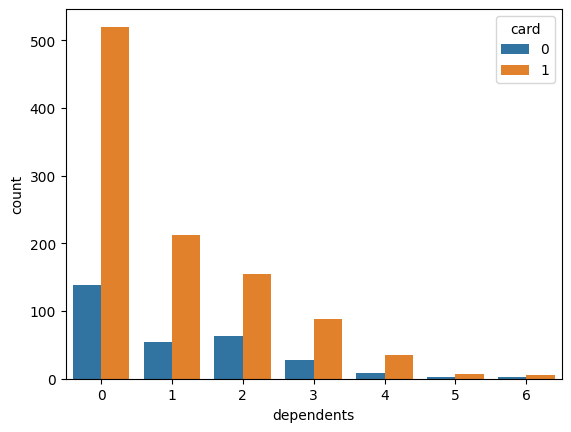

In [44]:
# Analyzing the effect of dependents on card
sns.countplot(x='dependents', hue='card', data=data_df)

With 0 dependents, the probability of card/loan getting issued is more than with more number of dependents

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score

In [19]:
X = data_df[['owner','reports','age','expenditure','selfemp','dependents','months','majorcards','active']]
Y = data_df['card']

In [20]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2, random_state=42)

In [22]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train,Y_train)

LogisticRegression(max_iter=1000)

In [23]:
y_pred = model.predict(X_test)

scores = accuracy_score(Y_test,y_pred)
print(scores)

0.9772727272727273


In [24]:
cm = confusion_matrix(Y_test,y_pred)
print(cm)

[[ 62   0]
 [  6 196]]


In [25]:
feature_names = X.columns
coefficients = pd.Series(model.coef_[0], index=feature_names)
print(coefficients)

owner          0.145491
reports       -1.264126
age            0.036963
expenditure    1.672050
selfemp        0.368759
dependents    -0.684671
months        -0.005206
majorcards     0.117230
active         0.056948
dtype: float64


In [30]:
new_applciation = pd.DataFrame({'owner':[0],'reports':[0],'age':[25],'expenditure':[20000], 'selfemp':[0],'dependents':[1],'months':[120],'majorcards':0,'active':[1]})

In [42]:
new_proba = model.predict_proba(new_applciation)[0]
print(new_proba)

[0. 1.]


In [43]:
if new_proba[0] > 0.5:
  print('Card will be issued')
else:
  print('Card will not be issued')

Card will not be issued
